---
title: C.3re tanglegrams 
author: Elgin Akin
date: 2025-05-19
---

Useful resources: 
- [baltic](https://github.com/evogytis/baltic/blob/master/docs/notebooks/austechia.ipynb)
- [A nice blog by Gytis on reassortment](https://evogytis.github.io/posts/2020/10/reassortment/)

# Plot HA colored by subclade


Tree height: 5.037421
Tree length: 1067.108164
annotations present

Numbers of objects in tree: 3928 (1601 nodes and 2327 leaves)



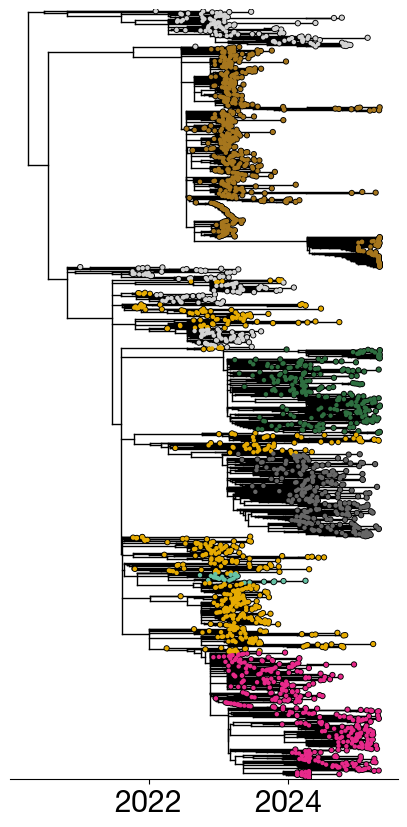

In [65]:
import baltic as bt
import matplotlib as mpl
from matplotlib import pyplot as plt

# set global fonts 

typeface='Helvetica Neue'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22

# Load tree
genome = "../auspice/vic/ha.json"

tree = bt.loadJSON(genome)

# Define your subclade color palette
subclade_colors = {
    "C.5.1": "#e7298a",
    "C.5.5": "#66c2a5",
    "C.5.6": "#2E6F40",
    "C.5.7": "#666666",
    "C.5": "#e6ab02",
    "C.3": "#a6761d"
}

# Define a color function for the tips
def c_func(node):
    subclade = node.traits.get('subclade')  # Get the 'subclade' attribute
    return subclade_colors.get(subclade, 'lightgrey')  # Default to grey if subclade is not in the palette

L=len(list(filter(lambda k: k.branchType=='leaf',tree[0].Objects)))
b_func=lambda k: 2+10.0*len(k.leaves)/float(L) if k.branchType=='node' else 2 ## branch width is determined by how many descendants a node has, otherwise 2 (tips)

fig, ax = plt.subplots(figsize=(5, 10), facecolor='w')

x_attr = lambda k: k.absoluteTime  # Use absolute time for x-axis

# Plot the tree and tips
tree[0].plotTree(ax,
                connection_type = "baltic",
                x_attr=x_attr, 
                colour='k',  # Plot tree branches in black
                width = 1,
                #width = b_func,
                #colour = c_func)
                )
tree[0].plotPoints(ax, 
                x_attr=x_attr, 
                size=10, 
                outline = True,
                outline_colour = "black", 
                colour=c_func, 
                zorder=100)  # Color tips based on subclade

# Aesthetics
ax.xaxis.tick_bottom()
ax.set_ylim(-5, tree[0].ySpan + 5)  # Adjust y-axis limits
ax.set_yticks([])  # Remove y-axis ticks
ax.set_yticklabels([])  # Remove y-axis labels
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]  # Hide spines except bottom

#plt.savefig('../figures/01_B_genome-tree-baltic',dpi=300, bbox_inches='tight')
plt.show()


## Tanglegram


> Copy over all auspice json's to a new sub-directory for easly looping and plotting


Sources: 
- https://github.com/dven42/phylogenetic-incongruence/blob/master/BALTIC.ipynb
- https://journals.plos.org/plospathogens/article?id=10.1371/journal.ppat.1006466
- https://github.com/blab/siv-cst/blob/master/figures/main-text/F1-recombination.ipynb

In [67]:
import baltic as bt

from IPython.display import HTML
import re
import copy

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon

import numpy as np
from scipy.special import binom
import itertools
import requests

from io import StringIO as sio
from io import BytesIO as csio

from Bio import Phylo


treefiles = glob('../auspice/plotting/*.json')


segments=['PB1','PB2','PA','HA','NP','NA','MP','NS']

trees={} ## dict
for segment in segments:
    print(segment, )
    tree_location = f"../auspice/vic/plotting/{segment}.json"

    ll = bt.loadJSON(tree_location)
    trees[segment]=ll[0] ## add ONLY the tree object to dict

print('\nDone!')

PB1

Tree height: 6.531678
Tree length: 1175.071381
annotations present

Numbers of objects in tree: 3882 (1519 nodes and 2363 leaves)

PB2

Tree height: 10.036744
Tree length: 1306.385383
annotations present

Numbers of objects in tree: 3921 (1557 nodes and 2364 leaves)

PB2

Tree height: 10.036744
Tree length: 1306.385383
annotations present

Numbers of objects in tree: 3921 (1557 nodes and 2364 leaves)

PA
PA

Tree height: 7.052922
Tree length: 1005.982341
annotations present

Numbers of objects in tree: 4031 (1666 nodes and 2365 leaves)

HA

Tree height: 7.052922
Tree length: 1005.982341
annotations present

Numbers of objects in tree: 4031 (1666 nodes and 2365 leaves)

HA

Tree height: 5.037421
Tree length: 1067.108164
annotations present

Numbers of objects in tree: 3928 (1601 nodes and 2327 leaves)

NP

Tree height: 5.037421
Tree length: 1067.108164
annotations present

Numbers of objects in tree: 3928 (1601 nodes and 2327 leaves)

NP

Tree height: 5.861070
Tree length: 1183.141

In [72]:
tip_positions={x:{} for x in segments} ## remember the position of each tip in each tree

for t,tr in enumerate(trees.keys()): ## iterate over trees
    cur_tree=trees[tr] ## fetch tree object
    for k in cur_tree.Objects:
        if k.branchType=='leaf':
            tip_positions[tr][k.name]=(k.height,k.y) ## remember (X, Y) position of tip

cmap=mpl.cm.Spectral

tip_positions={x:{} for x in trees} ## remember the position of each tip in each tree

for t,tr in enumerate(trees.keys()): ## iterate over trees
    cur_tree=trees[tr] ## fetch tree object
    for k in cur_tree.Objects:
        if k.branchType=='leaf':
            tip_positions[tr][k.name]=(k.height,k.y) ## remember (X, Y) position of tip

cmap=mpl.cm.Spectral

for X in range(1): ## 10 untangling iterations
    print('iteration %d'%(X+1))
    for t,tr in enumerate(segments): ## iterate over each tree
        print(tr)
        ptr=segments[t-1] ## previous tree
        ntr=segments[t] ## next tree
        seg=trees[ptr] ## fetch appropriate tree
        nex_seg=trees[ntr]
        for k in sorted(nex_seg.Objects,key=lambda q:q.height): ## iterate over branches from most recent to oldest
            if k.branchType=='node': ## can only sort nodes
                leaves=[w.leaves if w.branchType=='node' else [w.name] for w in k.children] ## descendent tips in current order
                
#                 leaves=[[seg.tipMap[tip] for tip in w.leaves] if w.branchType=='node' else [w.name] for w in k.children] ## descendent tips in current order
                
                for c in range(len(leaves)):
#                     leaves[c]=sorted(leaves[c],key=lambda x:tip_positions[ntr][x][1]) ## sort leaves according to their positions in the next tree
                    leaves[c]=sorted(leaves[c],key=lambda x:tip_positions[ntr][x][1] if x in tip_positions[ntr] else 0.0) ## sort leaves according to their positions in the next tree
                
                ys=[sorted([tip_positions[ntr][w][1] for w in cl if w in tip_positions[ntr]]) for cl in leaves] ## extract y positions of descendents
                merge_ys=sum(ys,[]) ## flatten list of tip y coordinates
                ypos=range(int(min(merge_ys)),int(max(merge_ys))+1) ## get y positions of tips in current order
                order={i:x for i,x in enumerate(leaves)} ## dict of tip order: tip name
                
                new_order=sorted(order.keys(),key=lambda x:-np.mean([(tip_positions[ptr][order[x][w]][1]-ypos[w]) for w in range(min([len(order[x]),len(ypos)])) if order[x][w] in tip_positions[ptr]])) ## get new order by sorting existing order based on y position differences
                
#                 new_order=sorted(order.keys(),key=lambda x:-np.mean([(tip_positions[ptr][order[x][w]][1]-ypos[w]) for w in range(len(order[x]))])) ## get new order by sorting existing order based on y position differences
                
                if new_order!=range(len(leaves)): ## if new order is not current order
                    k.children=[k.children[i] for i in new_order] ## assign new order of child branches
                    nex_seg.drawTree() ## update y positions

                    for w in nex_seg.Objects: ## iterate over objects in next tree
                        if w.branchType=='leaf':
                            tip_positions[ntr][w.name]=(w.height,w.y) ## remember new positions
                
        if t==0: ## if first tree
            trees[segments[t]].drawTree() ## update positions
            lvs=sorted([w for w in trees[segments[t]].Objects if w.branchType=='leaf'],key=lambda x:x.y) ## get leaves in y position order
            
            norm=mpl.colors.Normalize(0,len(lvs))
            pos_colours={w.name:cmap(norm(w.y)) for w in lvs} ## assign colour

iteration 1
PB1


KeyboardInterrupt: 

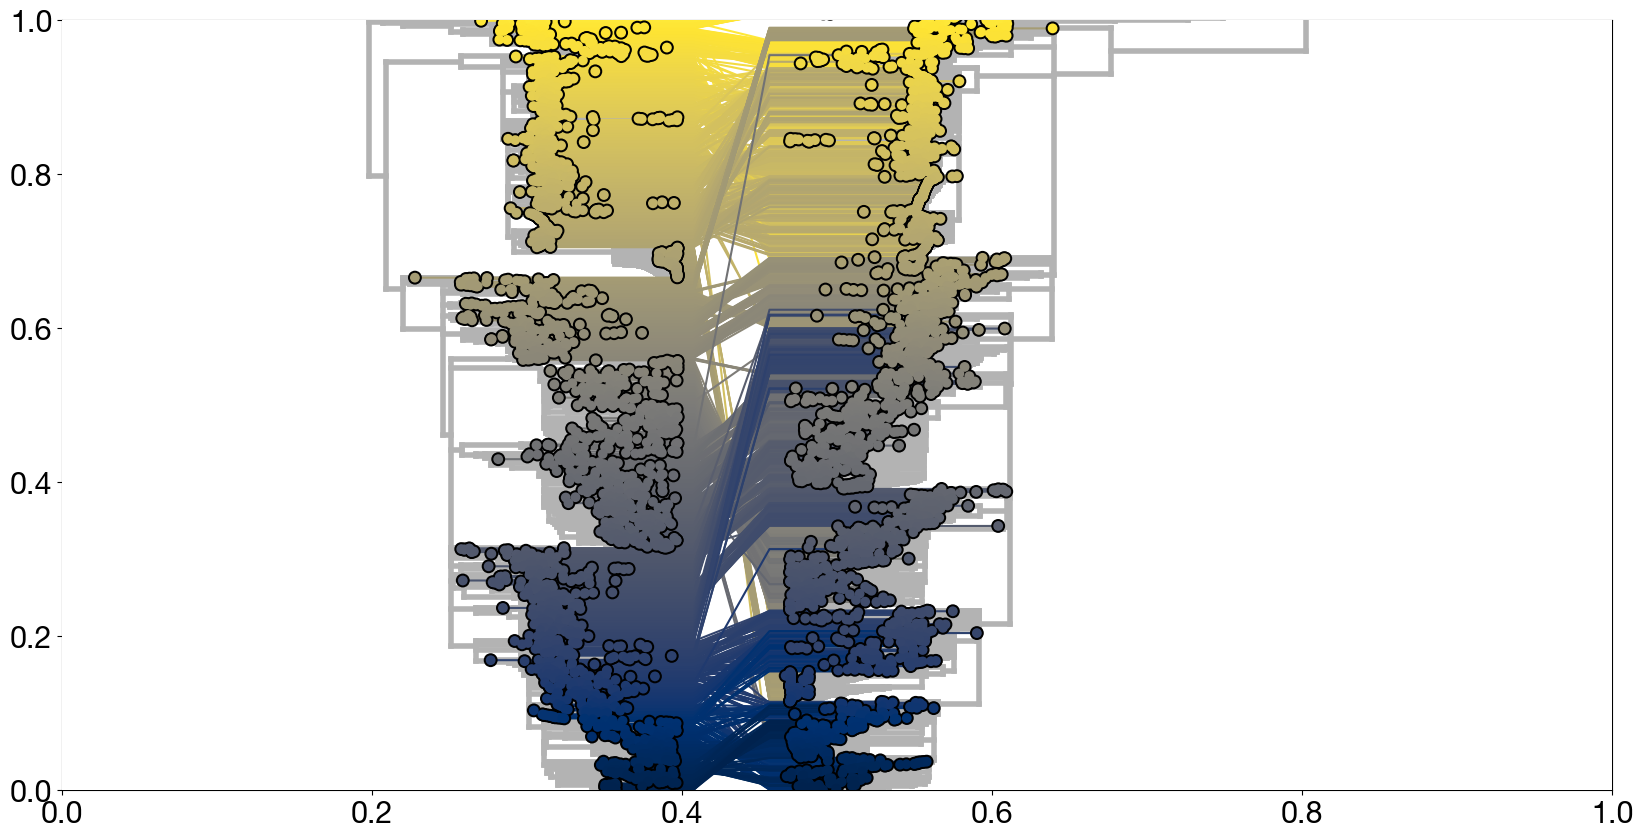

In [71]:

import baltic as bt

from IPython.display import HTML
import re
import copy

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon

import numpy as np
from scipy.special import binom
import itertools
import requests

from io import StringIO as sio
from io import BytesIO as csio

from Bio import Phylo

fig = plt.subplots(figsize=(20,10),facecolor='w')

gs = GridSpec(1, 1,hspace=0.0,wspace=0.0)
ax = plt.subplot(gs[0])

traitName='HA'
tree1=trees["PB1"]
tree2=trees["PB2"]

cmap=mpl.cm.cividis
x_attr=lambda k: k.height ## branch x position is determined by height
c_func=lambda k: 'indianred' if k.traits[traitName]=='C.3' else 'steelblue'
ct_func=lambda k: cmap(k.y/float(tree1.ySpan)) ## call colour map with fraction that represents the y position of a tip (returns colour)

tree1.plotTree(ax,x_attr=x_attr,width=4,colour=c_func) ## plot black tree
tree1.plotPoints(ax,x_attr=x_attr,size=50,colour=ct_func,zorder=100) ## plot circles at tips

skip=tree1.treeHeight*0.35 ## skip this many units between trees
x_attr=lambda k: tree1.treeHeight+skip+tree2.treeHeight-k.height ## for tree2 we'll offset x coordinates by the height of the tree and invert branches
tree2.plotTree(ax,x_attr=x_attr,width=4,colour=c_func) ## plot black tree
tree2.plotPoints(ax,x_attr=x_attr,size=50,colour=ct_func,zorder=100) ## plot circles at tips

for k in filter(lambda x: x.branchType=='leaf',tree1.Objects): ## grab leaf objects in tree1
    x=k.height ## get height
    y=k.y ## get y position
    
    matching_tip=tree2.getBranches(lambda x: x.branchType=='leaf' and x.name==k.name) ## fetch corresponding branch in tree2
    match_y=matching_tip.y
    xs=[x,tree1.treeHeight+0.15*skip,tree1.treeHeight+skip-0.15*skip,x_attr(matching_tip)] ## x coordinates for tangleline
    ys=[y,y,match_y,match_y] ## y coordinates for tangleline
    ax.plot(xs,ys,color=cmap(y/float(tree1.ySpan))) ## plot tangleline
    
[ax.spines[loc].set_visible(False) for loc in ['top','right','left','bottom']]

ax.tick_params(axis='x',size=0)
ax.tick_params(axis='y',size=0)
ax.set_xticklabels([])
ax.set_yticklabels([])

ax.set_ylim(-1,tree1.ySpan+1) ## set y limits
ax.set_xlim(-5,tree1.treeHeight+skip+tree2.treeHeight+5)

plt.show()

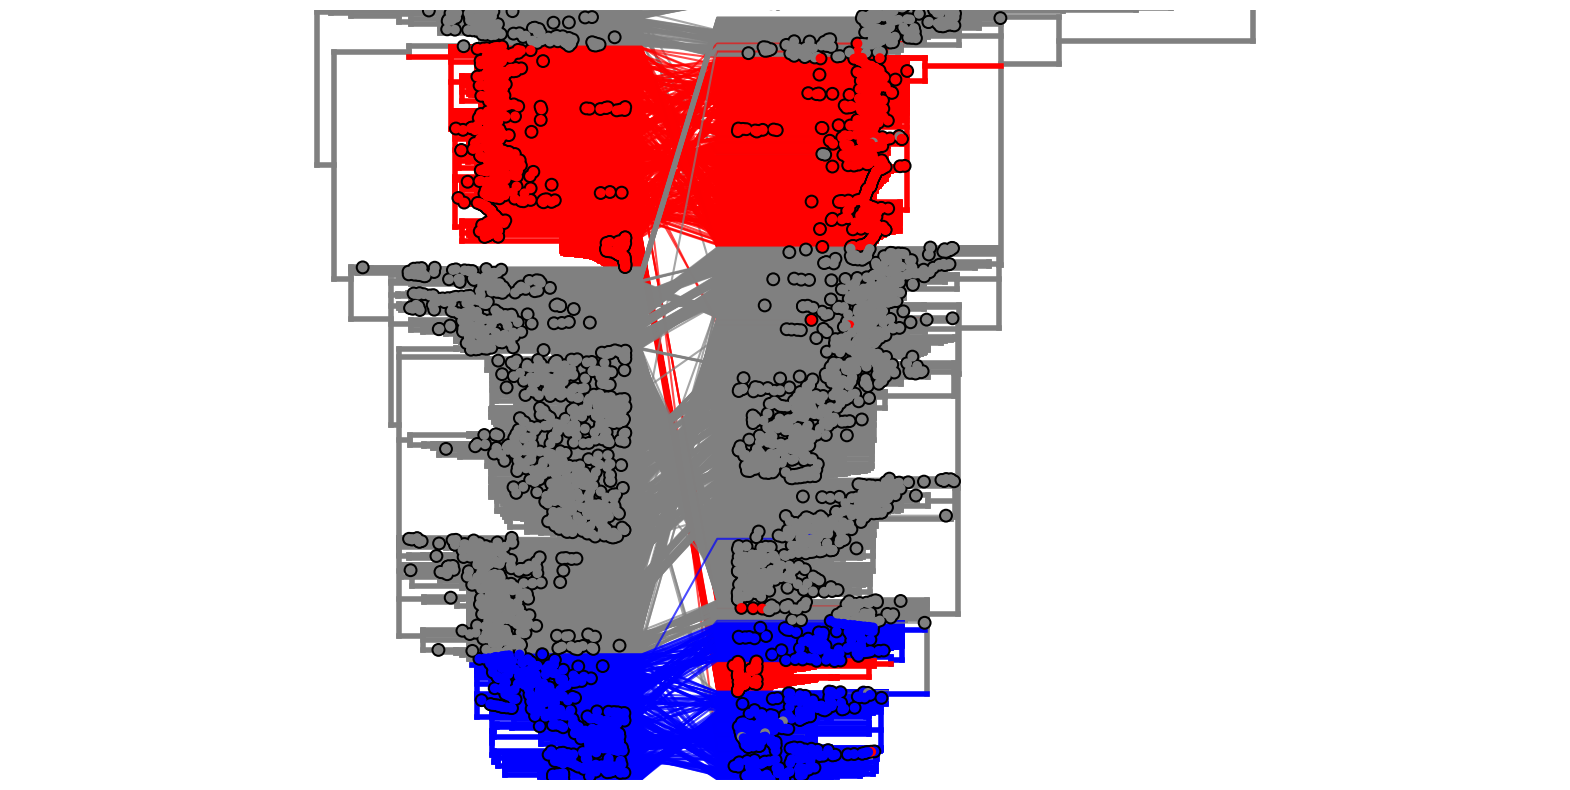

In [79]:
# Plot a tanglegram between PB1 and PB2, coloring by subclade

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

# Set up figure and axes
fig = plt.figure(figsize=(20, 10), facecolor='w')
gs = GridSpec(1, 1, hspace=0.0, wspace=0.0)
ax = plt.subplot(gs[0])

traitName = 'subclade'
tree1 = trees["HA"]
tree2 = trees["NA"]

# Color function for subclade
subclade_colors = {
    'C.3': 'red',
    'C.5.1': 'blue'
}
def c_func(k):
    return subclade_colors.get(k.traits.get(traitName), 'grey')

cmap = mpl.cm.cividis
x_attr1 = lambda k: k.height

# Plot first tree
tree1.plotTree(ax, x_attr=x_attr1, width=4, colour=c_func)
tree1.plotPoints(ax, x_attr=x_attr1, size=50, colour=c_func, zorder=100)

# Offset for second tree
skip = tree1.treeHeight * 0.35
x_attr2 = lambda k: tree1.treeHeight + skip + tree2.treeHeight - k.height

# Plot second tree
tree2.plotTree(ax, x_attr=x_attr2, width=4, colour=c_func)
tree2.plotPoints(ax, x_attr=x_attr2, size=50, colour=c_func, zorder=100)

# Draw tangle lines between matching tips
for k in filter(lambda x: x.branchType == 'leaf', tree1.Objects):
    x = k.height
    y = k.y
    # Set warn=False to avoid exceptions if no match is found
    matching = tree2.getBranches(lambda x2: x2.branchType == 'leaf' and x2.name == k.name, warn=False)
    if not matching:
        continue
    # Handle both list and single object return types
    if isinstance(matching, list):
        matching_tip = matching[0]
    else:
        matching_tip = matching
    match_y = matching_tip.y
    xs = [x, tree1.treeHeight + 0.15 * skip, tree1.treeHeight + skip - 0.15 * skip, x_attr2(matching_tip)]
    ys = [y, y, match_y, match_y]
    color = subclade_colors.get(k.traits.get(traitName), 'grey')
    ax.plot(xs, ys, color=color, alpha=0.7)

# Clean up plot aesthetics
for loc in ['top', 'right', 'left', 'bottom']:
    ax.spines[loc].set_visible(False)
ax.tick_params(axis='x', size=0)
ax.tick_params(axis='y', size=0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_ylim(-1, tree1.ySpan + 1)
ax.set_xlim(-5, tree1.treeHeight + skip + tree2.treeHeight + 5)

plt.show()

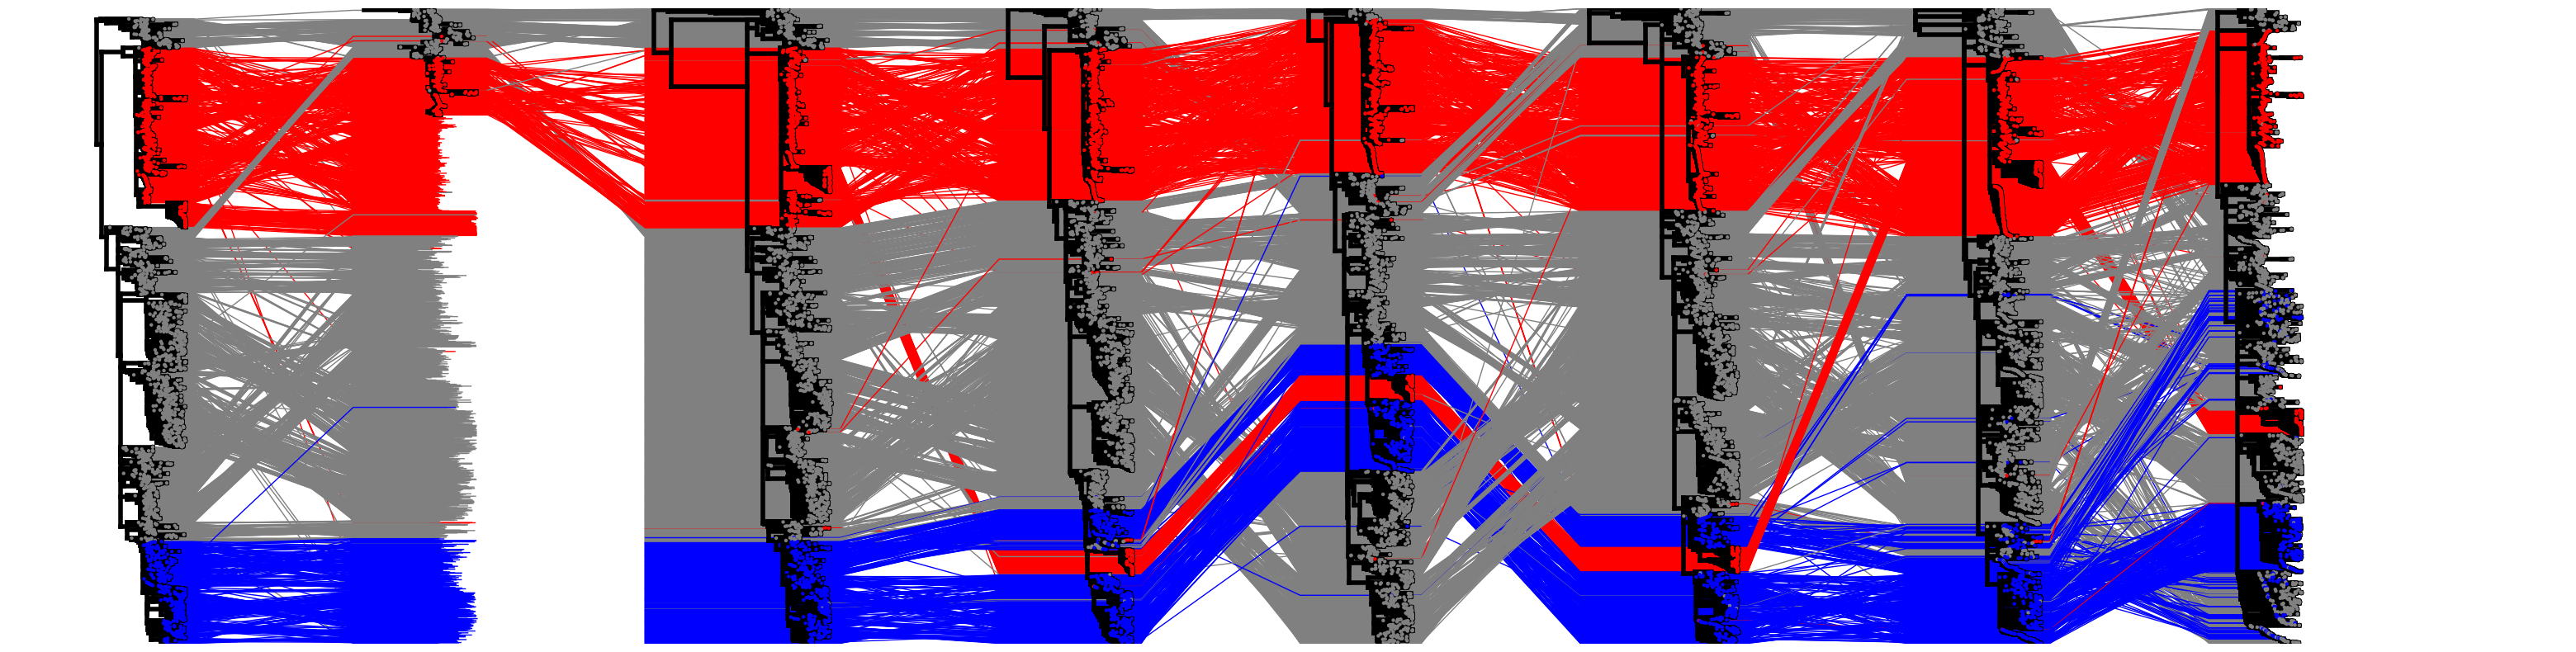

In [87]:
# Genome segment tanglegram: plot all segments side by side, color by subclade (C.3=red, C.5.1=blue, others=grey)

fig, ax = plt.subplots(figsize=(40, 10), facecolor='w')

traitName = 'subclade'  # choose a trait to colour branches by
cumulative_displace = 0  # this tracks the "current" x position, so trees are plotted one after another

tree_names = ['HA', 'PB1', 'PB2', 'PA', 'NP', 'NA', 'MP', 'NS']  # use your actual segment names

displaceAmount = 10
subclade_colors = {'C.3': 'red', 'C.5.1': 'blue'}

for t, tr in enumerate(tree_names):
    cur_tree = trees[tr]
    x_attr = lambda k: k.height + cumulative_displace
    # Color tips by subclade
    def colour_func(node):
        return subclade_colors.get(node.traits.get(traitName), 'grey')
    cn_func = colour_func
    ct_func = colour_func

    cur_tree.plotTree(ax, x_attr=x_attr, width=4, colour="black")
    cur_tree.plotPoints(ax, x_attr=x_attr, size=10, colour=ct_func, zorder=100)

    for k in cur_tree.Objects:
        if k.branchType == 'leaf':
            y = k.y
            # Only plot lines if tip exists in next tree
            if t != len(tree_names) - 1:
                next_tree = tree_names[t + 1]
                if k.name in tip_positions[next_tree]:
                    next_x, next_y = tip_positions[next_tree][k.name]
                    next_x += cumulative_displace + cur_tree.treeHeight + displaceAmount
                    nextIncrement = cumulative_displace + cur_tree.treeHeight
                    color = subclade_colors.get(k.traits.get(traitName), 'grey')
                    ax.plot([
                        x_attr(k),
                        nextIncrement + 0.05 * displaceAmount,
                        nextIncrement + 0.95 * displaceAmount,
                        next_x
                    ], [y, y, next_y, next_y], lw=1, ls='-', color=color, zorder=0)

    cumulative_displace += cur_tree.treeHeight + displaceAmount

[ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left', 'bottom']]
ax.tick_params(axis='x', size=0)
ax.tick_params(axis='y', size=0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_ylim(-1, cur_tree.ySpan + 1)
ax.set_xlim(-5, cumulative_displace + 5)

plt.show()